<a href="https://colab.research.google.com/github/Piyush1804-Apr/Piyush1804-Apr/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Stock Market Prediction And Forecasting Using Stacked LSTM

In [1]:
import pandas_datareader as pdr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pdr.get_data_tiingo('QQQ', api_key='6cbca726c5a80908ade0f47c65ec52fe126c0be4')

/usr/local/lib/python3.7/dist-packages/pandas_datareader/tiingo.py:234: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  return pd.concat(dfs, self._concat_axis)


In [3]:
df.to_csv('AAPL.csv')

In [4]:
df=pd.read_csv('AAPL.csv')

In [5]:
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,QQQ,2017-05-16 00:00:00+00:00,139.62,139.640,138.9900,139.36,21785994,134.566320,134.585596,133.959123,134.315731,21785994,0.0,1.0
1,QQQ,2017-05-17 00:00:00+00:00,136.07,138.770,136.0500,138.55,55642178,131.144816,133.747086,131.125539,133.535050,55642178,0.0,1.0
2,QQQ,2017-05-18 00:00:00+00:00,137.26,137.720,135.8700,136.06,41319882,132.291742,132.735092,130.952055,131.135177,41319882,0.0,1.0
3,QQQ,2017-05-19 00:00:00+00:00,137.84,138.420,137.6600,137.71,36730112,132.850749,133.409755,132.677264,132.725454,36730112,0.0,1.0
4,QQQ,2017-05-22 00:00:00+00:00,139.00,139.075,138.0967,138.14,19509659,133.968761,134.041047,133.098157,133.139890,19509659,0.0,1.0


In [6]:
df.shape

(1259, 14)

In [7]:
df1=df['close'] 

In [8]:
df1

0       139.62
1       136.07
2       137.26
3       137.84
4       139.00
         ...  
1254    297.15
1255    300.76
1256    291.84
1257    291.15
1258    301.94
Name: close, Length: 1259, dtype: float64

Text(0, 0.5, 'Closing Price')

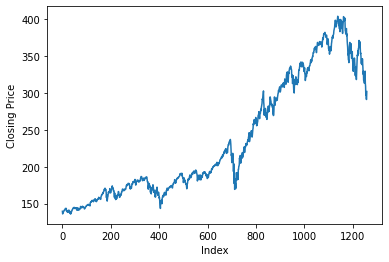

In [9]:
plt.plot(df1)
plt.xlabel('Index')
plt.ylabel('Closing Price')

In [10]:
# LSTM are sensitive to the scale of the data. so we apply MinMax scaler 

In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [12]:
df1.shape

(1259, 1)

In [13]:
# Splitting dataset into train and test split
training_size=int(len(df1)*0.67)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [14]:
training_size,test_size

(843, 416)

In [15]:
# convert an array of values into a dataset matrix i.e time series data into supervised learning data
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step)]   # i=0, 0,1,2,3-----99   100 
		dataX.append(a)
		dataY.append(dataset[i + time_step])
	return np.array(dataX), np.array(dataY)

In [16]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [17]:
print(X_train.shape) 
print(y_train.shape)

(742, 100, 1)
(742, 1)


In [18]:
print(X_test.shape)
print(ytest.shape)

(315, 100, 1)
(315, 1)


In [19]:
# Input in the form [samples, time steps, features] which is required for LSTM

In [20]:
print(X_train.shape)
print(X_test.shape)

(742, 100, 1)
(315, 100, 1)


In [21]:
# Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [22]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1))) # It expects to know the shape of inputs
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')


In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100, 50)           10400     
                                                                 
 lstm_1 (LSTM)               (None, 100, 50)           20200     
                                                                 
 lstm_2 (LSTM)               (None, 50)                20200     
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 50,851
Trainable params: 50,851
Non-trainable params: 0
_________________________________________________________________


In [24]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=2)

Epoch 1/100
12/12 - 13s - loss: 0.0200 - val_loss: 0.0930 - 13s/epoch - 1s/step
Epoch 2/100
12/12 - 4s - loss: 0.0043 - val_loss: 0.0077 - 4s/epoch - 358ms/step
Epoch 3/100
12/12 - 5s - loss: 0.0015 - val_loss: 0.0405 - 5s/epoch - 401ms/step
Epoch 4/100
12/12 - 4s - loss: 0.0010 - val_loss: 0.0103 - 4s/epoch - 347ms/step
Epoch 5/100
12/12 - 5s - loss: 9.2004e-04 - val_loss: 0.0058 - 5s/epoch - 397ms/step
Epoch 6/100
12/12 - 4s - loss: 8.4848e-04 - val_loss: 0.0094 - 4s/epoch - 321ms/step
Epoch 7/100
12/12 - 2s - loss: 8.2227e-04 - val_loss: 0.0071 - 2s/epoch - 188ms/step
Epoch 8/100
12/12 - 2s - loss: 7.9474e-04 - val_loss: 0.0050 - 2s/epoch - 188ms/step
Epoch 9/100
12/12 - 2s - loss: 7.6627e-04 - val_loss: 0.0025 - 2s/epoch - 189ms/step
Epoch 10/100
12/12 - 2s - loss: 7.7751e-04 - val_loss: 0.0023 - 2s/epoch - 189ms/step
Epoch 11/100
12/12 - 2s - loss: 7.6437e-04 - val_loss: 0.0028 - 2s/epoch - 190ms/step
Epoch 12/100
12/12 - 2s - loss: 6.9393e-04 - val_loss: 0.0025 - 2s/epoch - 190ms

In [25]:
import tensorflow as tf

In [26]:
# Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

In [27]:
# Transform back to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [28]:
train_predict.shape

(742, 1)

In [29]:
test_predict.shape

(315, 1)

In [30]:
# Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

192.25865628615114

In [31]:
# Test Data RMSE
math.sqrt(mean_squared_error(ytest,test_predict))

346.0175265450412

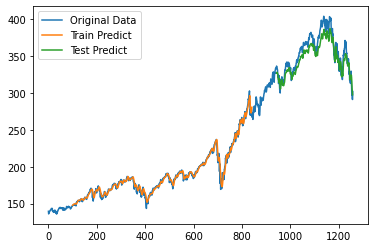

In [32]:
# Plotting and shifting predicted outcomes to match the original test data output
look_back=100
trainPredictPlot = np.empty_like(df1)  # Creates an empty array
trainPredictPlot[:, :] = np.nan # Tells that the values are undefined
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = np.empty_like(df1)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict
# Plot baseline and predictions
plt.plot(scaler.inverse_transform(df1),label="Original Data")
plt.plot(trainPredictPlot,label="Train Predict")
plt.plot(testPredictPlot,label="Test Predict")
plt.legend()
plt.show()

In [33]:
len(test_data)

416

In [34]:
x_input=test_data[316:].reshape(1,-1) # Row is 1 and columns are unknown
x_input.shape


(1, 100)

In [35]:
temp_input=list(x_input)  # Each input is in the form of list present in an array
temp_input=temp_input[0].tolist() # Converts the array into list

In [36]:
temp_input

[0.9448342788892206,
 0.9625261272021497,
 0.9736115258286056,
 0.9980964467005076,
 0.9911167512690355,
 0.9908928038220364,
 0.9864138548820542,
 0.9770827112570917,
 0.9913780232905345,
 0.9719319199761123,
 0.9264705882352942,
 0.9254628247237979,
 0.9099358017318602,
 0.9108689160943564,
 0.9321812481337712,
 0.9378919080322485,
 0.9017243953418932,
 0.9104956703493579,
 0.8751866228724992,
 0.8599955210510599,
 0.8422290235891312,
 0.8047924753657807,
 0.8108017318602567,
 0.7802329053448791,
 0.7782173783218871,
 0.765265750970439,
 0.8052030456852792,
 0.8471931919976112,
 0.8564123618990742,
 0.8674977605255298,
 0.8117348462227529,
 0.8283816064496863,
 0.8176321289937294,
 0.8325246342191699,
 0.8609286354135564,
 0.8299492385786802,
 0.7875111973723499,
 0.7891161540758436,
 0.8213645864437145,
 0.8210286652732159,
 0.7815019408778738,
 0.7667960585249327,
 0.7539937294714838,
 0.7216706479546133,
 0.7629889519259481,
 0.782696327261869,
 0.7865407584353539,
 0.766721409375

In [37]:
len(temp_input)

100

In [38]:
# demonstrate prediction for next 30 days
from numpy import array

lst_output=[]
n_steps=100
i=0
while(i<30):
    
    if(len(temp_input)>100):
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)  # Output after previous 100 days of input
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1
    
print(lst_output)

[0.6088498]
101
1 day input [0.96252613 0.97361153 0.99809645 0.99111675 0.9908928  0.98641385
 0.97708271 0.99137802 0.97193192 0.92647059 0.92546282 0.9099358
 0.91086892 0.93218125 0.93789191 0.9017244  0.91049567 0.87518662
 0.85999552 0.84222902 0.80479248 0.81080173 0.78023291 0.77821738
 0.76526575 0.80520305 0.84719319 0.85641236 0.86749776 0.81173485
 0.82838161 0.81763213 0.83252463 0.86092864 0.82994924 0.7875112
 0.78911615 0.82136459 0.82102867 0.78150194 0.76679606 0.75399373
 0.72167065 0.76298895 0.78269633 0.78654076 0.76672141 0.78810839
 0.7695954  0.75108241 0.70465064 0.69901463 0.74246044 0.72857569
 0.70293371 0.6796805  0.71693043 0.76235443 0.77773216 0.80404598
 0.79878322 0.82446253 0.80531502 0.83450284 0.8333831  0.85413556
 0.8775754  0.86227232 0.84528964 0.84271424 0.87052105 0.8399149
 0.81065243 0.8137877  0.79531203 0.76448193 0.7591072  0.78486115
 0.75530009 0.75627053 0.78452523 0.76567632 0.73932517 0.70666617
 0.72226784 0.67583607 0.67441774 0.7

In [39]:
import matplotlib.pyplot as plt

In [40]:
len(df1)

1259

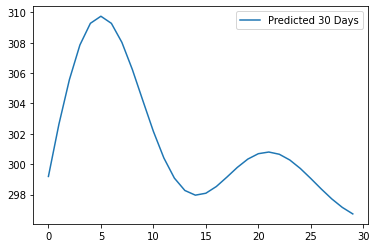

In [41]:
plt.plot(scaler.inverse_transform(lst_output),label='Predicted 30 Days')
plt.legend()

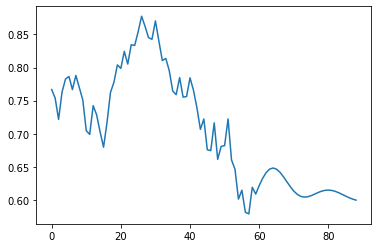

In [42]:
# Complete Output
df3=df1.tolist()
df3.extend(lst_output)
plt.plot(df3[1200:])

In [43]:
df3=scaler.inverse_transform(df3).tolist()

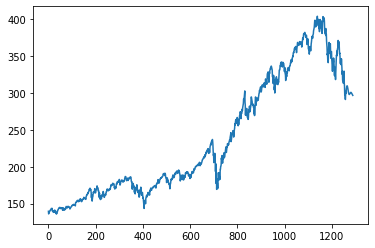

In [44]:
plt.plot(df3)